<a href="https://colab.research.google.com/github/nav1sak/ahb/blob/main/aihc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving 56364408.dcm to 56364408.dcm
Uploaded: 56364408.dcm


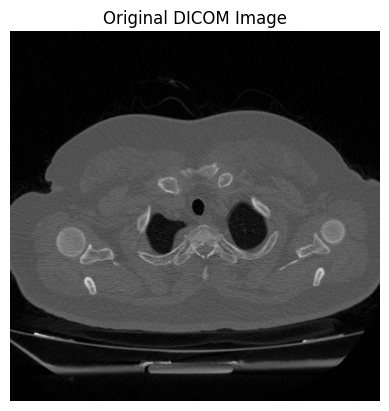

Image shape: (512, 512)


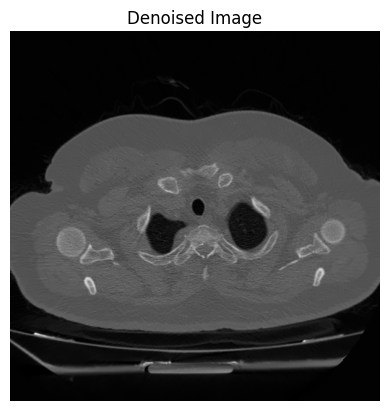

Tensor shapes: torch.Size([1, 3, 224, 224]) torch.Size([1, 3, 224, 224])
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 101MB/s] 



===== IMAGE QUALITY METRICS =====
Estimated MSE (orig vs denoised): 433.22983
Estimated PSNR (dB): 42.738853
Estimated SNR of original (dB): 30.929333

===== MODEL OUTPUT =====
Original logits: [[ 2.95109209e-02  1.54716039e+00 -1.22168314e+00  1.14433038e+00
   6.22757077e-01  5.24717522e+00  4.89557076e+00 -2.43514657e+00
  -1.31607294e+00 -4.19517088e+00 -3.30903649e+00 -2.46268344e+00
  -1.68283355e+00  5.61141431e-01 -2.13231659e+00 -1.18903995e+00
  -5.06743288e+00 -3.50143218e+00 -1.45508480e+00 -1.73942637e+00
  -3.11485314e+00 -1.71595252e+00 -2.03238559e+00  4.85804647e-01
  -1.34934819e+00  5.88426173e-01 -3.62166429e+00 -8.48620474e-01
   1.97749424e+00  4.62106794e-01 -3.58361095e-01  2.24260139e+00
   9.00146902e-01  3.06157172e-01  1.34902489e+00 -2.15000615e-01
   1.42700601e+00 -1.82543552e+00 -1.04974806e+00 -4.09626913e+00
  -2.95458937e+00 -5.06328154e+00 -3.33162332e+00 -4.13149166e+00
  -5.51119804e+00 -2.17602968e+00 -2.33531618e+00 -2.88693619e+00
  -3.17814636

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


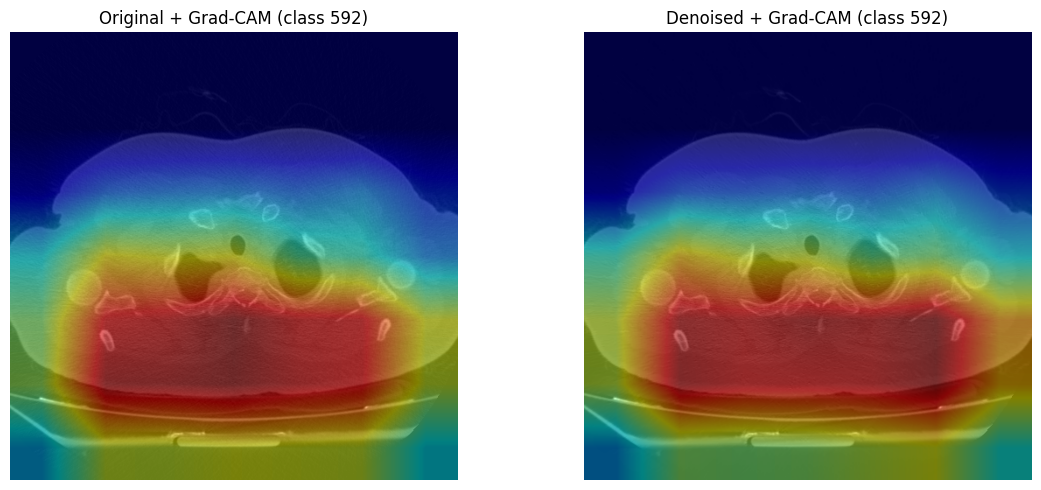

In [11]:


!pip install pydicom scikit-image opencv-python torch torchvision matplotlib numpy PyWavelets

import pydicom
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch
import torch.nn.functional as F
from google.colab import files
from skimage.restoration import denoise_nl_means, estimate_sigma
from torchvision import transforms, models

# STEP 1: Upload and display DICOM
uploaded = files.upload()
dicom_path = list(uploaded.keys())[0]
print("Uploaded:", dicom_path)

ds = pydicom.dcmread(dicom_path, force=True)
img = ds.pixel_array.astype(np.float32)

plt.imshow(img, cmap='gray')
plt.title("Original DICOM Image")
plt.axis('off')
plt.show()
print("Image shape:", img.shape)

# STEP 2: Apply Denoising
def denoise_image(img):
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-6)
    sigma_est = estimate_sigma(img_norm, average_sigmas=True)
    denoised = denoise_nl_means(
        img_norm,
        h=1.15 * sigma_est,
        fast_mode=True,
        patch_size=5,
        patch_distance=6
    )
    denoised = denoised * (img.max() - img.min()) + img.min()
    return denoised.astype(np.float32)

denoised_img = denoise_image(img)
plt.imshow(denoised_img, cmap='gray')
plt.title("Denoised Image")
plt.axis('off')
plt.show()

# STEP 3: Convert images to CNN tensor format
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224

def to_tensor(image):
    resized = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    norm = (resized - resized.min()) / (resized.max() - resized.min() + 1e-9)
    img_3ch = np.stack([norm] * 3, axis=-1)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    return transform(img_3ch).unsqueeze(0).to(device)

tensor_orig = to_tensor(img)
tensor_denoised = to_tensor(denoised_img)
print("Tensor shapes:", tensor_orig.shape, tensor_denoised.shape)

# STEP 4: Load Pretrained CNN Model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.eval().to(device)

# STEP 5: Register Hook to Extract Feature Map
feature_map = None
def forward_hook(module, input, output):
    global feature_map
    feature_map = output.detach()

target_layer = model.layer4[-1].conv2
target_layer.register_forward_hook(forward_hook)

# STEP 6: Forward pass
with torch.no_grad():
    logits_orig = model(tensor_orig)
    fmap_orig = feature_map.clone()
    logits_denoised = model(tensor_denoised)
    fmap_denoised = feature_map.clone()

# STEP 7: Image quality metrics
noise = img - denoised_img
mse = np.mean(noise ** 2)
max_I = img.max() - img.min() + 1e-8
psnr = 10 * np.log10((max_I ** 2) / (mse + 1e-8))

signal_power = np.mean(denoised_img ** 2)
noise_power = np.mean(noise ** 2) + 1e-8
snr_est = 10 * np.log10(signal_power / noise_power)

print("\n===== IMAGE QUALITY METRICS =====")
print("Estimated MSE (orig vs denoised):", mse)
print("Estimated PSNR (dB):", psnr)
print("Estimated SNR of original (dB):", snr_est)

# STEP 8: Grad-CAM implementation
gradients = None
def backward_hook(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0].detach()

target_layer.register_backward_hook(backward_hook)

def generate_gradcam(input_tensor, base_img):
    global feature_map, gradients
    model.zero_grad()
    output = model(input_tensor)
    class_idx = torch.argmax(output, dim=1).item()
    score = output[0, class_idx]
    score.backward(retain_graph=True)

    fmap = feature_map[0]
    grads = gradients[0]

    weights = torch.mean(grads, dim=(1, 2))
    cam = torch.zeros(fmap.shape[1:], dtype=torch.float32).to(fmap.device)

    for c, w in enumerate(weights):
        cam += w * fmap[c]

    cam = torch.relu(cam)
    cam = cam / (cam.max() + 1e-8)
    cam = cam.detach().cpu().numpy()

    H, W = base_img.shape
    cam_resized = cv2.resize(cam, (W, H))
    return cam_resized, class_idx, output.detach().cpu().numpy()

# RESULTS
print("\n===== MODEL OUTPUT =====")
print("Original logits:", logits_orig.cpu().numpy())
print("Denoised logits:", logits_denoised.cpu().numpy())

class_idx_orig = torch.argmax(logits_orig, dim=1).item()
final_score_orig = logits_orig[0, class_idx_orig].item()
class_idx_den = torch.argmax(logits_denoised, dim=1).item()
final_score_den = logits_denoised[0, class_idx_den].item()

print(f"Original: class={class_idx_orig} final score (logit)={final_score_orig}")
print(f"Denoised: class={class_idx_den} final score (logit)={final_score_den}")
print("Change in final score:", final_score_den - final_score_orig)

# STEP 9: Generate Grad-CAM for original vs denoised
cam_orig, cls_orig_gc, out_orig_gc = generate_gradcam(tensor_orig, img)
cam_den, cls_den_gc, out_den_gc = generate_gradcam(tensor_denoised, denoised_img)

def overlay_cam(base_img, cam):
    base_norm = (base_img - base_img.min()) / (base_img.max() - base_img.min() + 1e-8)
    base_uint8 = (base_norm * 255).astype(np.uint8)
    base_color = cv2.cvtColor(base_uint8, cv2.COLOR_GRAY2BGR)
    cam_uint8 = (cam * 255).astype(np.uint8)
    cam_color = cv2.applyColorMap(cam_uint8, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(base_color, 0.5, cam_color, 0.5, 0)
    return cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

overlay_orig = overlay_cam(img, cam_orig)
overlay_den = overlay_cam(denoised_img, cam_den)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(overlay_orig)
plt.title(f"Original + Grad-CAM (class {cls_orig_gc})")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(overlay_den)
plt.title(f"Denoised + Grad-CAM (class {cls_den_gc})")
plt.axis('off')
plt.tight_layout()
plt.show()